# Урок 15.14. Математическая статистика: выводы по данным

**Интерактивная версия:** `lessons/lesson_15_14/web/index.html`

После урока вы сможете:

- описывать данные мерами центра, разброса и формы, выбирать устойчивые характеристики и находить выбросы;
- объяснять выборочное распределение, считать стандартную ошибку, раскладывать MSE оценки на смещение² и дисперсию;
- строить оценки методом моментов, максимального правдоподобия и байесовским методом;
- строить доверительные интервалы (Стьюдент, Уилсон, бутстрэп) и планировать размер выборки;
- проверять гипотезы (биномиальный, t-, перестановочный, χ², Манн — Уитни) и учитывать множественные сравнения;
- честно оценивать и сравнивать модели: погрешность метрики, Мак-Немар, кросс-валидация с поправкой;
- видеть статистику внутри бустинга: разбиения на шуме, λ как байесовское сжатие, сдвиг данных.

Разделы идут в том же порядке, что и 34 шага урока (шесть блоков). Числа урока проверяются расчётом (`assert`),
ключевые — сверкой со `scipy.stats`, scikit-learn и `gbcourse`. Случайность — через генератор курса Mulberry32,
как в веб-версии: числа совпадают с виджетами.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math

import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate, stats
from sklearn.metrics import roc_auc_score

from gbcourse import datasets
from gbcourse.boosting import GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED

use_course_style()


def wait_times(rng, n, mean=10.0):
    """Время ожидания: экспоненциальное распределение (метод обратной функции, как на странице)."""
    return np.array([-mean * math.log(1 - rng.random()) for _ in range(n)])

## Интуиция. Кто победил на валидации?

Модель A на самом деле точнее (0.82 против 0.80). Вероятность, что на валидации из $n$ объектов B выглядит
не хуже A, считаем точно: $P(B \ge A) = \sum_a P(A = a)\,P(B \ge a)$.

In [2]:
def p_flip(n, pa=0.82, pb=0.80):
    a = stats.binom.pmf(np.arange(n + 1), n, pa)
    tail_b = stats.binom.sf(np.arange(n + 1) - 1, n, pb)
    return float((a * tail_b).sum())


for n in (200, 1000, 5000):
    print(f"n = {n:5d}: P(B не хуже A) = {p_flip(n):.4f}")
assert round(p_flip(200), 3) == 0.328 and round(p_flip(1000), 3) == 0.133 and round(p_flip(5000), 3) == 0.006
print("нужно n ≈", math.ceil(1.6449**2 * (0.82 * 0.18 + 0.8 * 0.2) / 0.02**2))

n =   200: P(B не хуже A) = 0.3276
n =  1000: P(B не хуже A) = 0.1331
n =  5000: P(B не хуже A) = 0.0056
нужно n ≈ 2081


## Блок 1. Описание данных (шаги 1–5)

Двенадцать доставок из шагов 2–4: среднее, медиана, усечённое среднее, разброс, квартили, MAD и правила выбросов.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


среднее 14.42, медиана 12.5, усечённое 10 % 12.9
s = 6.788 (без выброса 2.137); Q1 = 11.75, Q3 = 14.25, IQR = 2.5, MAD = 1.5
заборы Тьюки: [8.0, 18.0];  z(35) = 3.03
5 выбросов: s = 19.8, |z| > 3 нашло 0, медиана ± 3·MAD нашло 5
полоса DKW (95 %) при n = 100: ±0.136
полоса DKW (95 %) при n = 1000: ±0.043
Анскомб I: r = 0.816, прямая [0.5 3. ]
4 точки: r = 0.965


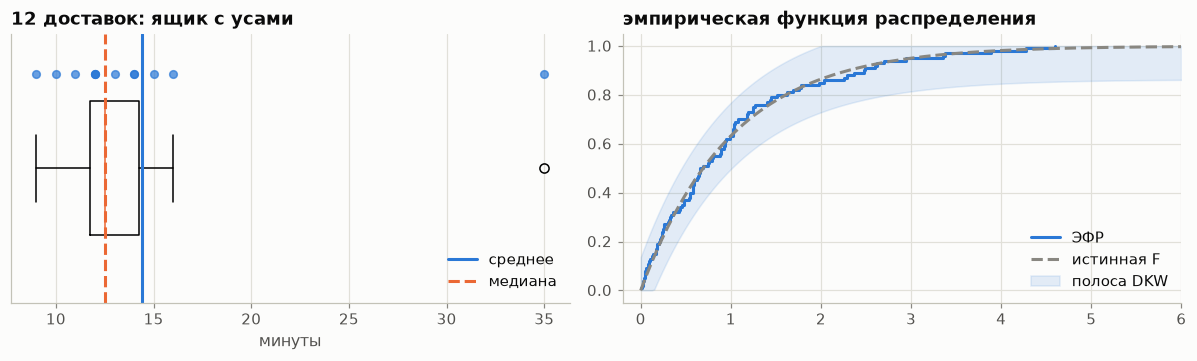

In [3]:
x = np.array([9, 10, 11, 12, 12, 12, 13, 14, 14, 15, 16, 35])
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
mad = np.median(np.abs(x - np.median(x)))
print(f"среднее {x.mean():.2f}, медиана {np.median(x)}, усечённое 10 % {stats.trim_mean(x, 0.1)}")
print(f"s = {x.std(ddof=1):.3f} (без выброса {np.r_[x[:-1], 15].std(ddof=1):.3f}); Q1 = {q1}, Q3 = {q3}, IQR = {iqr}, MAD = {mad}")
print(f"заборы Тьюки: [{q1 - 1.5 * iqr}, {q3 + 1.5 * iqr}];  z(35) = {(35 - x.mean()) / x.std(ddof=1):.2f}")
assert round(x.mean(), 2) == 14.42 and np.median(x) == 12.5 and stats.trim_mean(x, 0.1) == 12.9
assert (q1, q3, mad) == (11.75, 14.25, 1.5) and round(x.var(ddof=1), 2) == 46.08 and round(x.var(), 2) == 42.24

# маскировка: 30 значений около 50 и 5 выбросов около 100 (как в виджете)
rng = Mulberry32(3)
base = np.array([50 + 5 * rng.normal() for _ in range(30)])
y = np.r_[base, 100 + 2 * np.arange(5)]
z_found = np.sum(np.abs(y - y.mean()) > 3 * y.std(ddof=1))
madr = 1.4826 * np.median(np.abs(y - np.median(y)))
print(f"5 выбросов: s = {y.std(ddof=1):.1f}, |z| > 3 нашло {z_found}, медиана ± 3·MAD нашло {np.sum(np.abs(y - np.median(y)) > 3 * madr)}")
assert z_found == 0 and round(y.std(ddof=1), 1) == 19.8

# неравенство DKW и квартет Анскомба
for n in (100, 1000):
    print(f"полоса DKW (95 %) при n = {n}: ±{math.sqrt(math.log(40) / (2 * n)):.3f}")
ax_ = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5.0])
ay = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])
print(f"Анскомб I: r = {stats.pearsonr(ax_, ay).statistic:.3f}, прямая {np.polyfit(ax_, ay, 1).round(3)}")
print(f"4 точки: r = {np.corrcoef([1, 2, 3, 4], [2, 4, 5, 9])[0, 1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].boxplot(x, orientation="horizontal", widths=0.5)
axes[0].plot(x, np.full(len(x), 1.35), "o", color=BLUE, alpha=0.7)
axes[0].axvline(x.mean(), color=BLUE, label="среднее")
axes[0].axvline(np.median(x), color=ORANGE, ls="--", label="медиана")
axes[0].set(title="12 доставок: ящик с усами", xlabel="минуты", yticks=[])
axes[0].legend()
grid = np.linspace(-4, 8, 400)
for name, sample, color in [("экспоненциальное, n = 100", wait_times(Mulberry32(40), 100, 1.0), BLUE)]:
    srt = np.sort(sample)
    axes[1].step(srt, np.arange(1, len(srt) + 1) / len(srt), where="post", color=color, label="ЭФР")
    axes[1].plot(grid[grid >= 0], 1 - np.exp(-grid[grid >= 0]), "--", color=MUTED, label="истинная F")
    eps = math.sqrt(math.log(40) / 200)
    g = grid[grid >= 0]
    axes[1].fill_between(g, np.clip(1 - np.exp(-g) - eps, 0, 1), np.clip(1 - np.exp(-g) + eps, 0, 1), color=BLUE, alpha=0.12, label="полоса DKW")
axes[1].set(title="эмпирическая функция распределения", xlim=(-0.2, 6))
axes[1].legend()
plt.tight_layout()
plt.show()

## Блок 2. Оценки параметров (шаги 6–11)

### Шаг 6. Выборочное распределение и стандартная ошибка

In [4]:
rng = Mulberry32(7)
for n in (10, 100):
    means = np.array([wait_times(rng, n).mean() for _ in range(2000)])
    print(f"n = {n:3d}: разброс средних {means.std(ddof=1):.3f}, теория σ/√n = {10 / math.sqrt(n):.3f}")
print("SE доли 0.85 на 400 объектах:", round(math.sqrt(0.85 * 0.15 / 400), 4))

n =  10: разброс средних 3.129, теория σ/√n = 3.162


n = 100: разброс средних 1.002, теория σ/√n = 1.000
SE доли 0.85 на 400 объектах: 0.0179


### Шаги 7–8. Поправка Бесселя, MSE и сжатие

In [5]:
rng = Mulberry32(105)
v_n, v_n1 = [], []
for _ in range(5000):
    s = np.array([rng.normal() for _ in range(5)])
    v_n.append(s.var())
    v_n1.append(s.var(ddof=1))
print(f"n = 5: среднее при делении на n {np.mean(v_n):.4f} (теория 0.8), на n − 1 {np.mean(v_n1):.4f} (теория 1)")
assert abs(np.mean(v_n) - 0.8) < 0.02 and abs(np.mean(v_n1) - 1) < 0.025
print("E s при n = 2:", round(math.sqrt(2 / math.pi), 3), "σ")

mu, n = 0.5, 5
c = np.linspace(0, 1, 201)
mse = (1 - c) ** 2 * mu**2 + c**2 / n
c_star = mu**2 / (mu**2 + 1 / n)
print(f"c* = {c_star:.3f}, MSE(c*) = {mu**2 / n / (mu**2 + 1 / n):.4f} против 0.2")
assert round(c_star, 3) == 0.556
mse_k = {k: ((4 / k) - 1) ** 2 + 2 * 4 / k**2 for k in (4, 5, 6)}
print("MSE оценок дисперсии при n = 5 (в σ⁴), делители 4, 5, 6:", {k: round(v, 3) for k, v in mse_k.items()})
assert min(mse_k, key=mse_k.get) == 6

n = 5: среднее при делении на n 0.7959 (теория 0.8), на n − 1 0.9948 (теория 1)
E s при n = 2: 0.798 σ
c* = 0.556, MSE(c*) = 0.1111 против 0.2
MSE оценок дисперсии при n = 5 (в σ⁴), делители 4, 5, 6: {4: 0.5, 5: 0.36, 6: 0.333}


### Шаг 9. Эффективность: среднее против медианы

Асимптотическое отношение дисперсий $1/(4 f(m)^2)$ к дисперсии одного наблюдения.

In [6]:
ratio = {
    "нормальное": math.pi / 2,
    "Стьюдент, 3": 1 / (4 * stats.t.pdf(0, 3) ** 2) / 3,
    "Лаплас": 0.5,
    "засорённое": 1 / (4 * (0.91 * stats.norm.pdf(0)) ** 2) / 10.9,
}
for k, v in ratio.items():
    print(f"{k:12s}: Var(медианы)/Var(среднего) = {v:.3f}")
assert round(ratio["Стьюдент, 3"], 3) == 0.617 and round(ratio["засорённое"], 3) == 0.174

rng = Mulberry32(300 + 25)
mm, md = [], []
for _ in range(3000):
    s = np.array([rng.normal() for _ in range(25)])
    mm.append(s.mean())
    md.append(np.median(s))
print(f"симуляция n = 25 (нормальное): {np.var(md, ddof=1) / np.var(mm, ddof=1):.3f}")

нормальное  : Var(медианы)/Var(среднего) = 1.571
Стьюдент, 3 : Var(медианы)/Var(среднего) = 0.617
Лаплас      : Var(медианы)/Var(среднего) = 0.500
засорённое  : Var(медианы)/Var(среднего) = 0.174


симуляция n = 25 (нормальное): 1.561


### Шаг 10. Максимальное правдоподобие

Сверяем аналитические ОМП с численной максимизацией (`scipy.optimize`) и с `scipy.stats.*.fit`.

In [7]:
from scipy.optimize import minimize_scalar

k, n = 7, 10
res = minimize_scalar(lambda p: -(k * np.log(p) + (n - k) * np.log(1 - p)), bounds=(1e-6, 1 - 1e-6), method="bounded")
print(f"монета: численно p̂ = {res.x:.4f}, аналитически 0.7; SE = {math.sqrt(0.21 / 10):.3f}")
assert abs(res.x - 0.7) < 1e-4

w = wait_times(Mulberry32(11), 200, mean=2.0)
loc, scale = stats.expon.fit(w, floc=0)
print(f"экспоненциальное: 1/x̄ = {1 / w.mean():.4f}, scipy: {1 / scale:.4f}")
assert abs(1 / scale - 1 / w.mean()) < 1e-9

# Равномерное на [0, θ]: ОМП max (смещена), метод моментов 2x̄ (больше дисперсия)
rng = Mulberry32(12)
mle_u, mom_u = [], []
for _ in range(4000):
    s = np.array([10 * rng.random() for _ in range(10)])
    mle_u.append(s.max() * 11 / 10)
    mom_u.append(2 * s.mean())
print(f"θ = 10, n = 10: исправленная ОМП — среднее {np.mean(mle_u):.3f}, дисп. {np.var(mle_u):.3f} (теория {100 / 120:.3f}); 2x̄ — {np.mean(mom_u):.3f}, дисп. {np.var(mom_u):.3f} (теория {100 / 30:.3f})")

монета: численно p̂ = 0.7000, аналитически 0.7; SE = 0.145
экспоненциальное: 1/x̄ = 0.5340, scipy: 0.5340
θ = 10, n = 10: исправленная ОМП — среднее 9.973, дисп. 0.870 (теория 0.833); 2x̄ — 9.961, дисп. 3.373 (теория 3.333)


### Шаг 11. Байесовская оценка

Beta(2, 18) + 3 из 10: среднее 0.167, интервал [0.058 0.317]
A: 3 из 4 → 0.208   B: 300 из 500 → 0.581


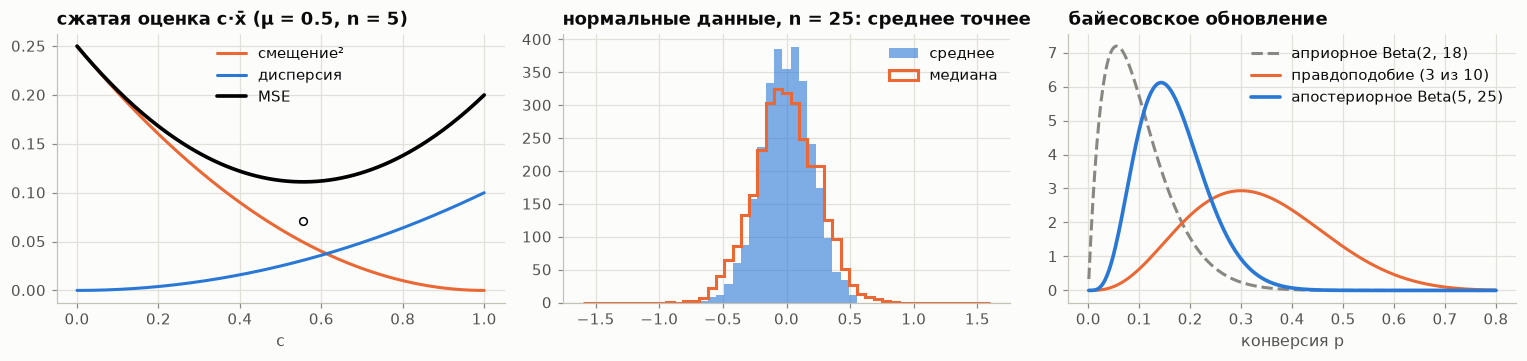

In [8]:
post = stats.beta(2 + 3, 18 + 7)
print(f"Beta(2, 18) + 3 из 10: среднее {post.mean():.3f}, интервал {post.ppf([0.025, 0.975]).round(3)}")
assert round(post.mean(), 3) == 0.167 and np.allclose(post.ppf([0.025, 0.975]).round(3), [0.058, 0.317])
print("A: 3 из 4 →", round(5 / 24, 3), "  B: 300 из 500 →", round(302 / 520, 3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(c, (1 - c) ** 2 * mu**2, color=ORANGE, label="смещение²")
axes[0].plot(c, c**2 / n, color=BLUE, label="дисперсия")
axes[0].plot(c, mse, color="black", lw=2.4, label="MSE")
axes[0].plot(c_star, mu**2 / n / (mu**2 + 1 / n), "o", mfc="white", mec="black")
axes[0].set(title="сжатая оценка c·x̄ (μ = 0.5, n = 5)", xlabel="c")
axes[0].legend()
bins = np.linspace(-1.6, 1.6, 50)
axes[1].hist(mm, bins=bins, color=BLUE, alpha=0.6, label="среднее")
axes[1].hist(md, bins=bins, histtype="step", color=ORANGE, lw=2, label="медиана")
axes[1].set(title="нормальные данные, n = 25: среднее точнее")
axes[1].legend()
p = np.linspace(0.001, 0.8, 400)
axes[2].plot(p, stats.beta(2, 18).pdf(p), "--", color=MUTED, label="априорное Beta(2, 18)")
axes[2].plot(p, stats.beta(4, 8).pdf(p), color=ORANGE, label="правдоподобие (3 из 10)")
axes[2].plot(p, post.pdf(p), color=BLUE, lw=2.4, label="апостериорное Beta(5, 25)")
axes[2].set(title="байесовское обновление", xlabel="конверсия p")
axes[2].legend()
plt.tight_layout()
plt.show()

## Блок 3. Доверительные интервалы (шаги 12–17)

In [9]:
print("квантили t₀.₉₇₅:", {k: round(float(stats.t.ppf(0.975, k)), 3) for k in (1, 2, 4, 9, 15, 29, 99)})
lo, hi = 52 - stats.t.ppf(0.975, 15) * 2, 52 + stats.t.ppf(0.975, 15) * 2
print(f"n = 16, x̄ = 52, s = 8: [{lo:.2f}, {hi:.2f}];  99 %: ±{stats.t.ppf(0.995, 15) * 2:.2f}")
assert (round(lo, 2), round(hi, 2)) == (47.74, 56.26)
print(f"интервал для дисперсии (n = 10, s² = 4): [{36 / stats.chi2.ppf(0.975, 9):.2f}, {36 / stats.chi2.ppf(0.025, 9):.2f}]")
print("размер выборки: σ = 10, E = 1 →", math.ceil((1.959964 * 10) ** 2), ";  ±3 % →", math.ceil(1.959964**2 * 0.25 / 0.03**2), ";  ±1 % →", math.ceil(1.959964**2 * 0.25 / 0.01**2))


# покрытие t-интервала на скошенных данных (как в виджете, seed 501)
def coverage_t(n, seed, R=4000):
    rng = Mulberry32(seed * 1000 + n)
    k = stats.t.ppf(0.975, n - 1)
    hits = 0
    for _ in range(R):
        s = wait_times(rng, n)
        h = k * s.std(ddof=1) / math.sqrt(n)
        hits += s.mean() - h <= 10 <= s.mean() + h
    return hits / R


cov10, cov100 = coverage_t(10, 501), coverage_t(100, 501)
print(f"покрытие t-интервала, время ожидания: n = 10 — {cov10:.1%}, n = 100 — {cov100:.1%}")
assert abs(cov10 - 0.903) < 6e-4 and abs(cov100 - 0.943) < 6e-4

квантили t₀.₉₇₅: {1: 12.706, 2: 4.303, 4: 2.776, 9: 2.262, 15: 2.131, 29: 2.045, 99: 1.984}
n = 16, x̄ = 52, s = 8: [47.74, 56.26];  99 %: ±5.89
интервал для дисперсии (n = 10, s² = 4): [1.89, 13.33]
размер выборки: σ = 10, E = 1 → 385 ;  ±3 % → 1068 ;  ±1 % → 9604


покрытие t-интервала, время ожидания: n = 10 — 90.3%, n = 100 — 94.3%


### Шаг 15. Вальд против Уилсона — точное покрытие

In [10]:
z = stats.norm.ppf(0.975)


def coverage(n, p, method):
    ks = np.arange(n + 1)
    ph = ks / n
    if method == "wald":
        h = z * np.sqrt(ph * (1 - ph) / n)
        lo, hi = ph - h, ph + h
    else:
        cc = (ph + z * z / (2 * n)) / (1 + z * z / n)
        h = z * np.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n)) / (1 + z * z / n)
        lo, hi = cc - h, cc + h
    return stats.binom.pmf(ks, n, p)[(lo <= p) & (p <= hi)].sum()


for p in (0.5, 0.1, 0.05, 0.01):
    print(f"n = 20, p = {p}: Вальд {coverage(20, p, 'wald'):.3f}, Уилсон {coverage(20, p, 'wilson'):.3f}")
assert round(coverage(20, 0.05, "wald"), 3) == 0.639 and round(coverage(20, 0.01, "wald"), 3) == 0.182
ci = stats.binomtest(0, 20).proportion_ci(method="wilson")
print(f"0 из 20: Уилсон [{ci.low:.3f}, {ci.high:.3f}], Клоппер — Пирсон {stats.binomtest(0, 20).proportion_ci(method='exact').high:.3f}, правило трёх {3 / 20}")

n = 20, p = 0.5: Вальд 0.959, Уилсон 0.959
n = 20, p = 0.1: Вальд 0.876, Уилсон 0.957
n = 20, p = 0.05: Вальд 0.639, Уилсон 0.925
n = 20, p = 0.01: Вальд 0.182, Уилсон 0.983
0 из 20: Уилсон [0.000, 0.161], Клоппер — Пирсон 0.168, правило трёх 0.15


### Шаги 16–17. Бутстрэп и его границы

In [11]:
w40 = wait_times(Mulberry32(33), 40)
r2 = Mulberry32(44)
boot = np.array([np.median(w40[r2.bootstrap(40)]) for _ in range(2000)])
print(f"медиана {np.median(w40):.2f}, бутстрэп-SE {boot.std(ddof=1):.2f}, интервал {np.percentile(boot, [2.5, 97.5]).round(2)}")
assert round(np.median(w40), 2) == 8.72 and round(boot.std(ddof=1), 2) == 1.19
# сверка с SciPy (тот же принцип, другой генератор — числа близки, но не равны)
res = stats.bootstrap((w40,), np.median, method="percentile", n_resamples=2000, random_state=0)
print("scipy.stats.bootstrap:", np.round([res.confidence_interval.low, res.confidence_interval.high], 2))

# бутстрэп максимума: перцентильный интервал никогда не накрывает θ = 1
rng = Mulberry32(12345)
hits = 0
for _ in range(200):
    u = np.array([rng.random() for _ in range(20)])
    bm = [u[[rng.randint(20) for _ in range(20)]].max() for _ in range(200)]
    hits += np.quantile(bm, 0.025) <= 1 <= np.quantile(bm, 0.975)
print("покрытие бутстрэп-интервала для максимума:", hits / 200)
assert hits == 0

медиана 8.72, бутстрэп-SE 1.19, интервал [ 6.92 11.74]
scipy.stats.bootstrap: [ 6.7  11.74]


покрытие бутстрэп-интервала для максимума: 0.0


## Блок 4. Проверка гипотез (шаги 18–25)

In [12]:
print("60 из 100:", round(stats.binomtest(60, 100).pvalue, 4), " односторонний:", round(stats.binomtest(60, 100, alternative="greater").pvalue, 4))
print("600 из 1000:", f"{stats.binomtest(600, 1000).pvalue:.1e}", "  чай: 1/70 =", round(1 / 70, 4))
assert round(stats.binomtest(60, 100).pvalue, 4) == 0.0569

zc = stats.norm.ppf(0.975)
for d in (0.2, 0.3, 0.5):
    print(f"d = {d}: n для мощности 80 % = {math.ceil(((zc + stats.norm.ppf(0.8)) / d) ** 2)}")
print("мощность d = 0.3, n = 50:", round(stats.norm.sf(zc - 0.3 * math.sqrt(50)), 3))

# t-критерии на данных виджета (seed 919)
rng = Mulberry32(919)
a, b = [], []
for _ in range(12):
    base_ = 30 + 5 * rng.normal()
    a.append(base_ + 1.5 * rng.normal())
    b.append(base_ - 1 + 1.5 * rng.normal())
a, b = np.array(a), np.array(b)
pw, pp = stats.ttest_ind(a, b, equal_var=False).pvalue, stats.ttest_rel(a, b).pvalue
print(f"Уэлч p = {pw:.3f}, парный p = {pp:.4f}, корреляция {np.corrcoef(a, b)[0, 1]:.2f}")
assert round(pw, 3) == 0.149 and round(pp, 4) == 0.0015
print("одновыборочный: t = 2.4, df = 8 → p =", round(2 * stats.t.sf(2.4, 8), 3))

# перестановочный тест вручную: A = {6, 8, 9}, B = {2, 4, 5}
from itertools import combinations

vals = [6, 8, 9, 2, 4, 5]
diffs = [(2 * sum(cmb) - 34) / 3 for cmb in combinations(vals, 3)]
print("перестановочный p (все 20 разбиений):", np.mean(np.abs(diffs) >= 4))

60 из 100: 0.0569  односторонний: 0.0284
600 из 1000: 2.7e-10   чай: 1/70 = 0.0143
d = 0.2: n для мощности 80 % = 197
d = 0.3: n для мощности 80 % = 88
d = 0.5: n для мощности 80 % = 32
мощность d = 0.3, n = 50: 0.564
Уэлч p = 0.149, парный p = 0.0015, корреляция 0.87
одновыборочный: t = 2.4, df = 8 → p = 0.043
перестановочный p (все 20 разбиений): 0.1


### Шаг 22. Распределение p-значений и подглядывание

In [13]:
def p_values(d, n, peek, seed):
    rng = Mulberry32(seed)
    ps = []
    for _ in range(2000):
        total, p = 0.0, 1.0
        for i in range(1, n + 1):
            total += rng.normal(d, 1)
            if peek and i % 10 == 0:
                p = 2 * stats.norm.sf(abs(total) / math.sqrt(i))
                if p < 0.05:
                    break
        if not peek:
            p = 2 * stats.norm.sf(abs(total) / math.sqrt(n))
        ps.append(p)
    return np.array(ps)


p_fix = p_values(0, 100, False, 1400)
p_peek = p_values(0, 100, True, 1400)
print(f"доля p < 0.05: один раз в конце {np.mean(p_fix < 0.05):.1%}, подглядывание {np.mean(p_peek < 0.05):.1%}")
assert abs(np.mean(p_fix < 0.05) - 0.048) < 1e-3 and abs(np.mean(p_peek < 0.05) - 0.181) < 1e-3

доля p < 0.05: один раз в конце 4.8%, подглядывание 18.1%


### Шаги 24–25. χ², Манн — Уитни и AUC

кубики: 0.963 0.02
тариф × отток: χ² = 65.96, df = 2, p = 4.7e-15, V = 0.257
A/B ×1: p = 0.16
A/B ×4: p = 0.0046
A/B ×10: p = 7.3e-06
U = 5, AUC = U/6 = 0.8333, roc_auc_score = 0.8333
AUC = 0.6 при 50 и 100: z = 1.99, p = 0.046


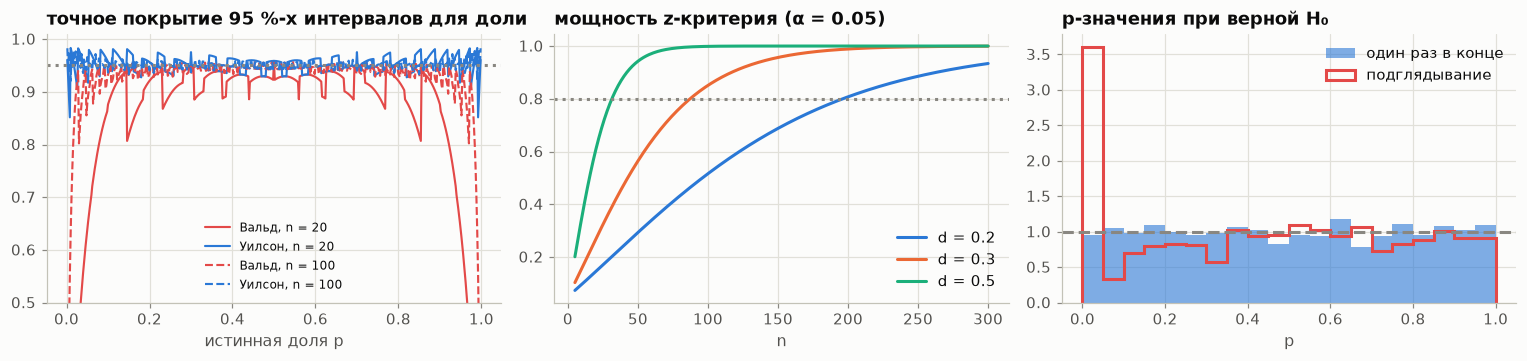

In [14]:
print("кубики:", stats.chisquare([9, 11, 8, 12, 10, 10]).pvalue.round(3), stats.chisquare([5, 8, 9, 8, 10, 20]).pvalue.round(3))
O = np.array([[120, 280], [49, 301], [15, 235]])
chi2, p, df, _ = stats.chi2_contingency(O, correction=False)
print(f"тариф × отток: χ² = {chi2:.2f}, df = {df}, p = {p:.1e}, V = {math.sqrt(chi2 / O.sum()):.3f}")
assert round(chi2, 1) == 66.0
AB = np.array([[180, 820], [205, 795]])
for mult in (1, 4, 10):
    print(f"A/B ×{mult}: p = {stats.chi2_contingency(AB * mult, correction=False)[1]:.2g}")

pos, neg = np.array([3, 5, 7]), np.array([1, 4])
u = stats.mannwhitneyu(pos, neg).statistic
print(f"U = {u:.0f}, AUC = U/6 = {u / 6:.4f}, roc_auc_score = {roc_auc_score([1, 1, 1, 0, 0], [3, 5, 7, 1, 4]):.4f}")
assert abs(u / 6 - roc_auc_score([1, 1, 1, 0, 0], [3, 5, 7, 1, 4])) < 1e-12
zz = (3000 - 2500) / math.sqrt(50 * 100 * 151 / 12)
print(f"AUC = 0.6 при 50 и 100: z = {zz:.2f}, p = {2 * stats.norm.sf(zz):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
pg = np.linspace(0.002, 0.998, 499)
for n_, ls in ((20, "-"), (100, "--")):
    axes[0].plot(pg, [coverage(n_, q, "wald") for q in pg], ls, color=RED, lw=1.4, label=f"Вальд, n = {n_}")
    axes[0].plot(pg, [coverage(n_, q, "wilson") for q in pg], ls, color=BLUE, lw=1.4, label=f"Уилсон, n = {n_}")
axes[0].axhline(0.95, color=MUTED, ls=":")
axes[0].set(ylim=(0.5, 1.01), title="точное покрытие 95 %-х интервалов для доли", xlabel="истинная доля p")
axes[0].legend(fontsize=8)
ns = np.arange(5, 301)
for d, color in ((0.2, BLUE), (0.3, ORANGE), (0.5, AQUA)):
    axes[1].plot(ns, stats.norm.sf(zc - d * np.sqrt(ns)) + stats.norm.cdf(-zc - d * np.sqrt(ns)), color=color, label=f"d = {d}")
axes[1].axhline(0.8, color=MUTED, ls=":")
axes[1].set(title="мощность z-критерия (α = 0.05)", xlabel="n")
axes[1].legend()
axes[2].hist(p_fix, bins=20, range=(0, 1), density=True, color=BLUE, alpha=0.6, label="один раз в конце")
axes[2].hist(p_peek, bins=20, range=(0, 1), density=True, histtype="step", color=RED, lw=2, label="подглядывание")
axes[2].axhline(1, color=MUTED, ls="--")
axes[2].set(title="p-значения при верной H₀", xlabel="p")
axes[2].legend()
plt.tight_layout()
plt.show()

## Блок 5. Много проверок (шаги 26–27)

In [15]:
pv = np.array([0.001, 0.008, 0.012, 0.038, 0.20])
m = len(pv)
bonf = np.sum(pv <= 0.05 / m)
srt = np.sort(pv)
fail = np.nonzero(srt > 0.05 / (m - np.arange(m)))[0]
holm = fail[0] if len(fail) else m
bh = np.sum(stats.false_discovery_control(pv) <= 0.05)
print(f"Бонферрони {bonf}, Холм {holm}, BH {bh}")
assert (bonf, holm, bh) == (2, 3, 4)
print("FWER при 20 и 100 проверках:", round(1 - 0.95**20, 3), round(1 - 0.95**100, 3))

emax = {k: integrate.quad(lambda t, k=k: t * k * stats.norm.pdf(t) * stats.norm.cdf(t) ** (k - 1), -10, 10)[0] for k in (2, 5, 10, 20, 50, 100)}
print("средний максимум k нормальных:", {k: round(v, 2) for k, v in emax.items()})
assert round(emax[50], 2) == 2.25 and round(emax[100], 2) == 2.51

Бонферрони 2, Холм 3, BH 4
FWER при 20 и 100 проверках: 0.642 0.994
средний максимум k нормальных: {2: 0.56, 5: 1.16, 10: 1.54, 20: 1.87, 50: 2.25, 100: 2.51}


## Блок 6. Статистика в машинном обучении (шаги 28–34)

### Шаги 28–29. Погрешность метрики и критерий Мак-Немара

In [16]:
for n in (100, 1000, 10000):
    print(f"SE точности 0.85 при n = {n}: {math.sqrt(0.85 * 0.15 / n):.4f}")
p_mc = stats.binomtest(30, 80, 0.5).pvalue
pb = 0.86
p_un = 2 * stats.norm.sf(0.02 / math.sqrt(2 * pb * (1 - pb) / 1000))
print(f"Мак-Немар (30 против 50): p = {p_mc:.3f};  непарный z: p = {p_un:.3f}")
assert round(p_mc, 3) == 0.033 and round(p_un, 2) == 0.20
print("непарно отличить 0.85 и 0.86 (мощность 80 %):", math.ceil((1.959964 + 0.8416) ** 2 * (0.85 * 0.15 + 0.86 * 0.14) / 0.01**2), "объектов на модель")

SE точности 0.85 при n = 100: 0.0357
SE точности 0.85 при n = 1000: 0.0113
SE точности 0.85 при n = 10000: 0.0036
Мак-Немар (30 против 50): p = 0.033;  непарный z: p = 0.197
непарно отличить 0.85 и 0.86 (мощность 80 %): 19458 объектов на модель


### Шаг 30. Кросс-валидация с поправкой Надо — Бенжио (бустинг `gbcourse`)

In [17]:
Xw, yw = datasets.regression_1d(kind="wave", n=120, noise=0.45, seed=4)


def cv_diffs(K, reps):
    out = []
    for rep in range(reps):
        perm = np.array(Mulberry32(8 + 1000 * rep).permutation(len(yw)))
        for k in range(K):
            test = perm[np.arange(len(yw)) % K == k]
            train = np.setdiff1d(np.arange(len(yw)), test)
            mse = [np.mean((yw[test] - GBRegressor(n_estimators=60, learning_rate=0.1, max_depth=dp).fit(Xw[train], yw[train]).predict(Xw[test])) ** 2) for dp in (1, 3)]
            out.append(mse[0] - mse[1])
    return np.array(out)


for reps in (1, 10):
    d = cv_diffs(5, reps)
    J = len(d)
    se_n = d.std(ddof=1) / math.sqrt(J)
    se_c = math.sqrt((1 / J + 1 / 4) * d.var(ddof=1))
    print(f"r = {reps:2d}: разность {d.mean():.4f}, SE наивная {se_n:.3f}, с поправкой {se_c:.3f}, p = {2 * stats.t.sf(abs(d.mean() / se_c), J - 1):.2f}")
    if reps == 1:
        assert abs(d.mean() - 0.0396) < 1e-4 and abs(se_c - 0.044) < 1e-3

r =  1: разность 0.0396, SE наивная 0.029, с поправкой 0.044, p = 0.42


r = 10: разность 0.0114, SE наивная 0.007, с поправкой 0.024, p = 0.64


### Шаг 32. Лучшее разбиение на шуме

Доля дисперсии, «объяснённая» лучшим разбиением из $p$ шумовых признаков, — по тому же алгоритму, что и в виджете.

In [18]:
def best_gain(yo, bounds, min_leaf):
    cs, tot, n = np.cumsum(yo), yo.sum(), len(yo)
    bnd = np.array([q for q in bounds if min_leaf <= q <= n - min_leaf])
    if len(bnd) == 0:
        return 0.0
    left = cs[bnd - 1]
    return max(0.0, (left**2 / bnd + (tot - left) ** 2 / (n - bnd) - tot**2 / n).max())


def noise_split(n=100, p=20, card=0, min_leaf=5, signal=0.3, R=300):
    rng = Mulberry32(2100 + n + 7 * p + 13 * card)
    allb = np.arange(1, n)
    nb, sg = [], []
    for _ in range(R):
        x0 = np.array([rng.random() for _ in range(n)])
        yy = np.array([signal * (1 if v > 0.5 else -1) + rng.normal() for v in x0])
        sst = ((yy - yy.mean()) ** 2).sum()
        sg.append(best_gain(yy[np.argsort(x0, kind="stable")], allb, min_leaf) / sst)
        best = 0.0
        for _ in range(p):
            sh = list(yy)
            rng.shuffle(sh)
            bounds = allb
            if card:
                cnt = np.zeros(card, int)
                for _ in range(n):
                    cnt[rng.randint(card)] += 1
                cc = np.cumsum(cnt)[:-1]
                bounds = cc[(cc > 0) & (cc < n)]
            best = max(best, best_gain(np.array(sh), bounds, min_leaf) / sst)
        nb.append(best)
    return np.array(nb), np.array(sg)


nb, sg = noise_split()
print(f"шум: средний лучший R² {nb.mean():.3f}, 95-й перцентиль {np.quantile(nb, 0.95):.3f}; сигнал {sg.mean():.3f}, выиграл в {np.mean(sg > nb):.0%}")
assert abs(nb.mean() - 0.102) < 1e-3 and abs(np.mean(sg > nb) - 0.55) < 5e-3
nb2, _ = noise_split(card=2)
print(f"бинарные шумовые признаки: средний лучший R² {nb2.mean():.3f}")

шум: средний лучший R² 0.102, 95-й перцентиль 0.148; сигнал 0.118, выиграл в 55%


бинарные шумовые признаки: средний лучший R² 0.050


### Шаг 33. λ в листе как байесовское сжатие

In [19]:
rng = Mulberry32(2201)
nl, mul, yl = [], [], []
for _ in range(40):
    nj = max(1, round(math.exp(rng.random() * math.log(200))))
    mj = 0.5 * rng.normal()
    nl.append(nj)
    mul.append(mj)
    yl.append(mj + rng.normal() / math.sqrt(nj))
nl, mul, yl = map(np.array, (nl, mul, yl))
lams = np.r_[0, np.geomspace(0.25, 128, 81)]
errs = np.array([np.mean((nl * yl / (nl + lam) - mul) ** 2) for lam in lams])
print(f"ошибка² листьев: λ = 0 — {errs[0]:.4f}, λ = 4 — {np.mean((nl * yl / (nl + 4) - mul) ** 2):.4f}, лучшее λ ≈ {lams[errs.argmin()]:.2f}")
assert abs(errs[0] - 0.217) < 1e-3

ошибка² листьев: λ = 0 — 0.2167, λ = 4 — 0.0491, лучшее λ ≈ 3.83


### Шаг 34. Сдвиг данных: Колмогоров — Смирнов и PSI

D = 0.100, p = 9.0e-05, PSI = 0.043


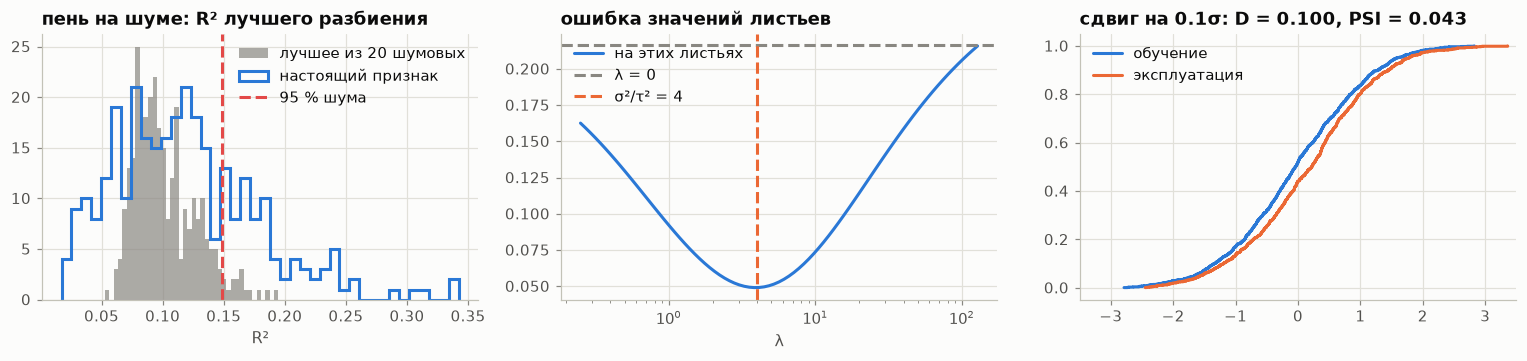

In [20]:
rng = Mulberry32(2300)
train = np.array([rng.normal() for _ in range(1000)])
rng = Mulberry32(2400 + 31 + 1000)
new = np.array([0.1 + rng.normal() for _ in range(1000)])
ks = stats.ks_2samp(train, new)
edges = np.quantile(train, np.arange(1, 10) / 10)
q = np.maximum(np.bincount(np.searchsorted(edges, new), minlength=10) / len(new), 1e-4)
psi = float(np.sum((q - 0.1) * np.log(q / 0.1)))
print(f"D = {ks.statistic:.3f}, p = {ks.pvalue:.1e}, PSI = {psi:.3f}")
assert abs(ks.statistic - 0.100) < 1e-3 and abs(psi - 0.043) < 1e-3

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].hist(nb, bins=40, color=MUTED, alpha=0.7, label="лучшее из 20 шумовых")
axes[0].hist(sg, bins=40, histtype="step", color=BLUE, lw=2, label="настоящий признак")
axes[0].axvline(np.quantile(nb, 0.95), color=RED, ls="--", label="95 % шума")
axes[0].set(title="пень на шуме: R² лучшего разбиения", xlabel="R²")
axes[0].legend()
axes[1].semilogx(lams[1:], errs[1:], color=BLUE, lw=2, label="на этих листьях")
axes[1].axhline(errs[0], color=MUTED, ls="--", label="λ = 0")
axes[1].axvline(4, color=ORANGE, ls="--", label="σ²/τ² = 4")
axes[1].set(title="ошибка значений листьев", xlabel="λ")
axes[1].legend()
for smp, color, lab in ((train, BLUE, "обучение"), (new, ORANGE, "эксплуатация")):
    sv = np.sort(smp)
    axes[2].step(sv, np.arange(1, len(sv) + 1) / len(sv), where="post", color=color, label=lab)
axes[2].set(title=f"сдвиг на 0.1σ: D = {ks.statistic:.3f}, PSI = {psi:.3f}", xlim=(-3.5, 3.5))
axes[2].legend()
plt.tight_layout()
plt.show()

## Упражнения

Задания — в `exercises/tasks.md`, решения — в `exercises/solutions.py`.